# Analisis Klaim Asuransi: Perspektif Musim / Season

Analisis ini **melampaui hari libur tunggal** — setiap musim (season) mencakup **rentang waktu penuh**:
- Ramadan = 30 hari penuh puasa
- Lebaran = periode sebelum–sesudah Eid
- Natal & Tahun Baru = liburan akhir tahun
- dsb.

Fokus analisis:
- **Total & rata-rata klaim** per season
- **Nominal klaim** per season
- **Processing Days (proses pencairan)** per season
- **Timeline** klaim harian dengan blok warna season

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

## 1. Definisi Season & Palet Warna

In [2]:
# ============================================================
# DEFINISI SEASON — setiap entri: (nama, start, end, warna hex)
# Urutan penting: jika tumpang tindih, season lebih awal menang
# ============================================================
SEASONS_DEF = [
    # --- 2024 ---
    # Tahun Baru 2024
    ('Tahun Baru',        '2024-01-01', '2024-01-07',  '#E63946'),  # merah
    # Isra Mi'raj + Imlek
    ('Imlek & Isra Miraj','2024-02-05', '2024-02-14',  '#F4A261'),  # oranye
    # Ramadan 2024: 12 Mar – 9 Apr 2024
    ('Ramadan',           '2024-03-12', '2024-04-09',  '#8ECAE6'),  # biru muda
    # Lebaran / Eid al-Fitr (H-3 s.d. H+7)
    ('Lebaran / Eid al-Fitr', '2024-04-07', '2024-04-18', '#219EBC'),  # biru
    # Long Weekend Mei (Buruh + Kenaikan Yesus + Waisak)
    ('Libur Panjang Mei', '2024-05-01', '2024-05-26',  '#2D6A4F'),  # hijau tua
    # Libur Idul Adha + Sekolah (Jun–Jul)
    ('Musim Liburan Sekolah', '2024-06-17', '2024-07-14', '#52B788'),  # hijau
    # Kemerdekaan (H-3 s.d. H+3)
    ('HUT Kemerdekaan',   '2024-08-14', '2024-08-20',  '#F7B731'),  # kuning
    # Maulid Nabi
    ('Maulid Nabi',       '2024-09-13', '2024-09-19',  '#B5838D'),  # ungu muda
    # Pilkada
    ('Hari Pilkada',      '2024-11-25', '2024-11-29',  '#6D6875'),  # abu ungu
    # Nataru 2024/2025 (20 Des – 7 Jan 2025)
    ('Natal & Tahun Baru','2024-12-20', '2025-01-07',  '#C9184A'),  # merah tua

    # --- 2025 ---
    # Isra Miraj + Imlek 2025
    ('Imlek & Isra Miraj','2025-01-24', '2025-02-02',  '#F4A261'),
    # Ramadan 2025: 1 Mar – 29 Mar 2025
    ('Ramadan',           '2025-03-01', '2025-03-30',  '#8ECAE6'),
    # Lebaran 2025 (H-3 s.d. H+7)
    ('Lebaran / Eid al-Fitr', '2025-03-28', '2025-04-08', '#219EBC'),
    # Libur Panjang Mei 2025 (Buruh + Waisak + Kenaikan)
    ('Libur Panjang Mei', '2025-05-01', '2025-05-30',  '#2D6A4F'),
    # Idul Adha + Liburan Sekolah 2025
    ('Musim Liburan Sekolah', '2025-06-06', '2025-07-13', '#52B788'),
    # Kemerdekaan 2025
    ('HUT Kemerdekaan',   '2025-08-14', '2025-08-21',  '#F7B731'),
    # Maulid Nabi 2025
    ('Maulid Nabi',       '2025-09-02', '2025-09-08',  '#B5838D'),
    # Nataru 2025/2026
    ('Natal & Tahun Baru','2025-12-20', '2025-12-31',  '#C9184A'),
]

# Palet warna per nama season (unik)
SEASON_PALETTE = {
    'Tahun Baru':             '#E63946',
    'Imlek & Isra Miraj':     '#F4A261',
    'Ramadan':                '#8ECAE6',
    'Lebaran / Eid al-Fitr':  '#219EBC',
    'Libur Panjang Mei':      '#2D6A4F',
    'Musim Liburan Sekolah':  '#52B788',
    'HUT Kemerdekaan':        '#F7B731',
    'Maulid Nabi':            '#B5838D',
    'Hari Pilkada':           '#6D6875',
    'Natal & Tahun Baru':     '#C9184A',
    'Hari Biasa':             '#DEE2E6',
}

# Buat DataFrame kalender season
rows = []
for name, start, end, color in SEASONS_DEF:
    for d in pd.date_range(start, end):
        rows.append({'date': d, 'season': name, 'season_color': color})

df_season = pd.DataFrame(rows).drop_duplicates(subset='date', keep='first')  # season lebih awal menang
print(f'Kalender season: {len(df_season)} hari')
print(df_season['season'].value_counts())

Kalender season: 291 hari
season
Musim Liburan Sekolah    66
Ramadan                  59
Libur Panjang Mei        56
Natal & Tahun Baru       31
Imlek & Isra Miraj       20
Lebaran / Eid al-Fitr    18
HUT Kemerdekaan          15
Maulid Nabi              14
Tahun Baru                7
Hari Pilkada              5
Name: count, dtype: int64


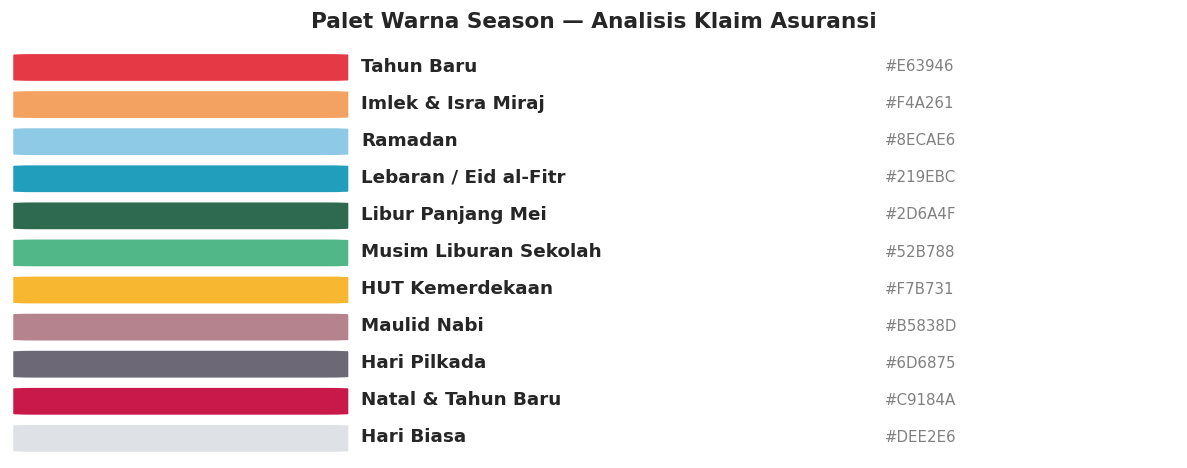

In [3]:
# Visualisasi palet warna season
fig, ax = plt.subplots(figsize=(10, 4))
ax.set_xlim(0, 1)
ax.set_ylim(0, len(SEASON_PALETTE))
ax.axis('off')

for i, (name, color) in enumerate(SEASON_PALETTE.items()):
    y = len(SEASON_PALETTE) - i - 1
    ax.add_patch(mpatches.FancyBboxPatch((0.02, y + 0.1), 0.25, 0.75,
                  boxstyle='round,pad=0.02', facecolor=color, edgecolor='white', linewidth=1.5))
    ax.text(0.30, y + 0.5, name, va='center', fontsize=11, fontweight='bold')
    ax.text(0.75, y + 0.5, color, va='center', fontsize=9, color='gray')

ax.set_title('Palet Warna Season — Analisis Klaim Asuransi', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## 2. Load Data & Mapping Season

In [4]:
df_klaim = pd.read_csv('dataset/Data_Klaim_Enriched.csv', parse_dates=[
    'Tanggal Pembayaran Klaim', 'Tanggal Pasien Masuk RS', 'Tanggal Pasien Keluar RS'
])

# Merge season berdasarkan tanggal MASUK RS
df = df_klaim.merge(df_season, left_on='Tanggal Pasien Masuk RS', right_on='date', how='left')
df['season'] = df['season'].fillna('Hari Biasa')
df['season_color'] = df['season_color'].fillna(SEASON_PALETTE['Hari Biasa'])

# Merge season pembayaran
df = df.merge(
    df_season[['date','season']].rename(columns={'season': 'season_bayar'}),
    left_on='Tanggal Pembayaran Klaim', right_on='date', how='left', suffixes=('', '_bayar')
).drop(columns=['date_bayar'], errors='ignore')
df['season_bayar'] = df['season_bayar'].fillna('Hari Biasa')

print('Distribusi season (berdasarkan Tgl Masuk RS):')
print(df['season'].value_counts())
print(f'\nTotal klaim: {len(df):,}')

Distribusi season (berdasarkan Tgl Masuk RS):
season
Hari Biasa               2689
Musim Liburan Sekolah     536
Ramadan                   494
Libur Panjang Mei         434
Lebaran / Eid al-Fitr     103
Natal & Tahun Baru        100
Imlek & Isra Miraj        100
Hari Pilkada               53
Tahun Baru                 46
HUT Kemerdekaan            40
Maulid Nabi                30
Name: count, dtype: int64

Total klaim: 4,625


## 3. Overview: Klaim per Season

In [5]:
# Jumlah hari per season (normalisasi)
hari_per_season = df_season['season'].value_counts().reset_index()
hari_per_season.columns = ['season', 'n_hari_season']
# tambah Hari Biasa
total_days = (pd.Timestamp('2025-12-31') - pd.Timestamp('2024-01-01')).days + 1
hari_biasa = total_days - len(df_season)
hari_per_season = pd.concat([
    hari_per_season,
    pd.DataFrame([{'season': 'Hari Biasa', 'n_hari_season': hari_biasa}])
], ignore_index=True)

# Agregasi
agg = df.groupby('season').agg(
    total_klaim=('Claim ID', 'count'),
    total_nominal=('Nominal Klaim Yang Disetujui', 'sum'),
    avg_nominal=('Nominal Klaim Yang Disetujui', 'mean'),
    avg_proc=('Processing_Days', 'mean'),
    median_proc=('Processing_Days', 'median')
).reset_index()

agg = agg.merge(hari_per_season, on='season', how='left')
agg['klaim_per_hari'] = agg['total_klaim'] / agg['n_hari_season']
agg['nominal_per_hari'] = agg['total_nominal'] / agg['n_hari_season']

# Urut: Hari Biasa di akhir, sisanya diurutkan by total klaim
agg_biasa = agg[agg['season'] == 'Hari Biasa']
agg_season = agg[agg['season'] != 'Hari Biasa'].sort_values('total_klaim', ascending=False)
agg = pd.concat([agg_season, agg_biasa], ignore_index=True)

agg[['season','total_klaim','n_hari_season','klaim_per_hari',
     'avg_nominal','avg_proc','median_proc']].round(1)

,season,total_klaim,n_hari_season,klaim_per_hari,avg_nominal,avg_proc,median_proc
0,Musim Liburan Sekolah,536,66,8.1,57224390.6,65.5,63.0
1,Ramadan,494,59,8.4,54155608.0,71.1,64.5
2,Libur Panjang Mei,434,56,7.8,48947528.5,67.7,66.0
3,Lebaran / Eid al-Fitr,103,18,5.7,57023498.2,69.2,58.0
4,Natal & Tahun Baru,100,31,3.2,36170272.7,50.6,51.5
5,Imlek & Isra Miraj,100,20,5.0,54763628.0,67.1,60.0
6,Hari Pilkada,53,5,10.6,50875592.7,54.4,54.0
7,Tahun Baru,46,7,6.6,54005973.0,90.6,64.5
8,HUT Kemerdekaan,40,15,2.7,39995319.0,67.0,64.5
9,Maulid Nabi,30,14,2.1,41140611.4,66.1,62.0


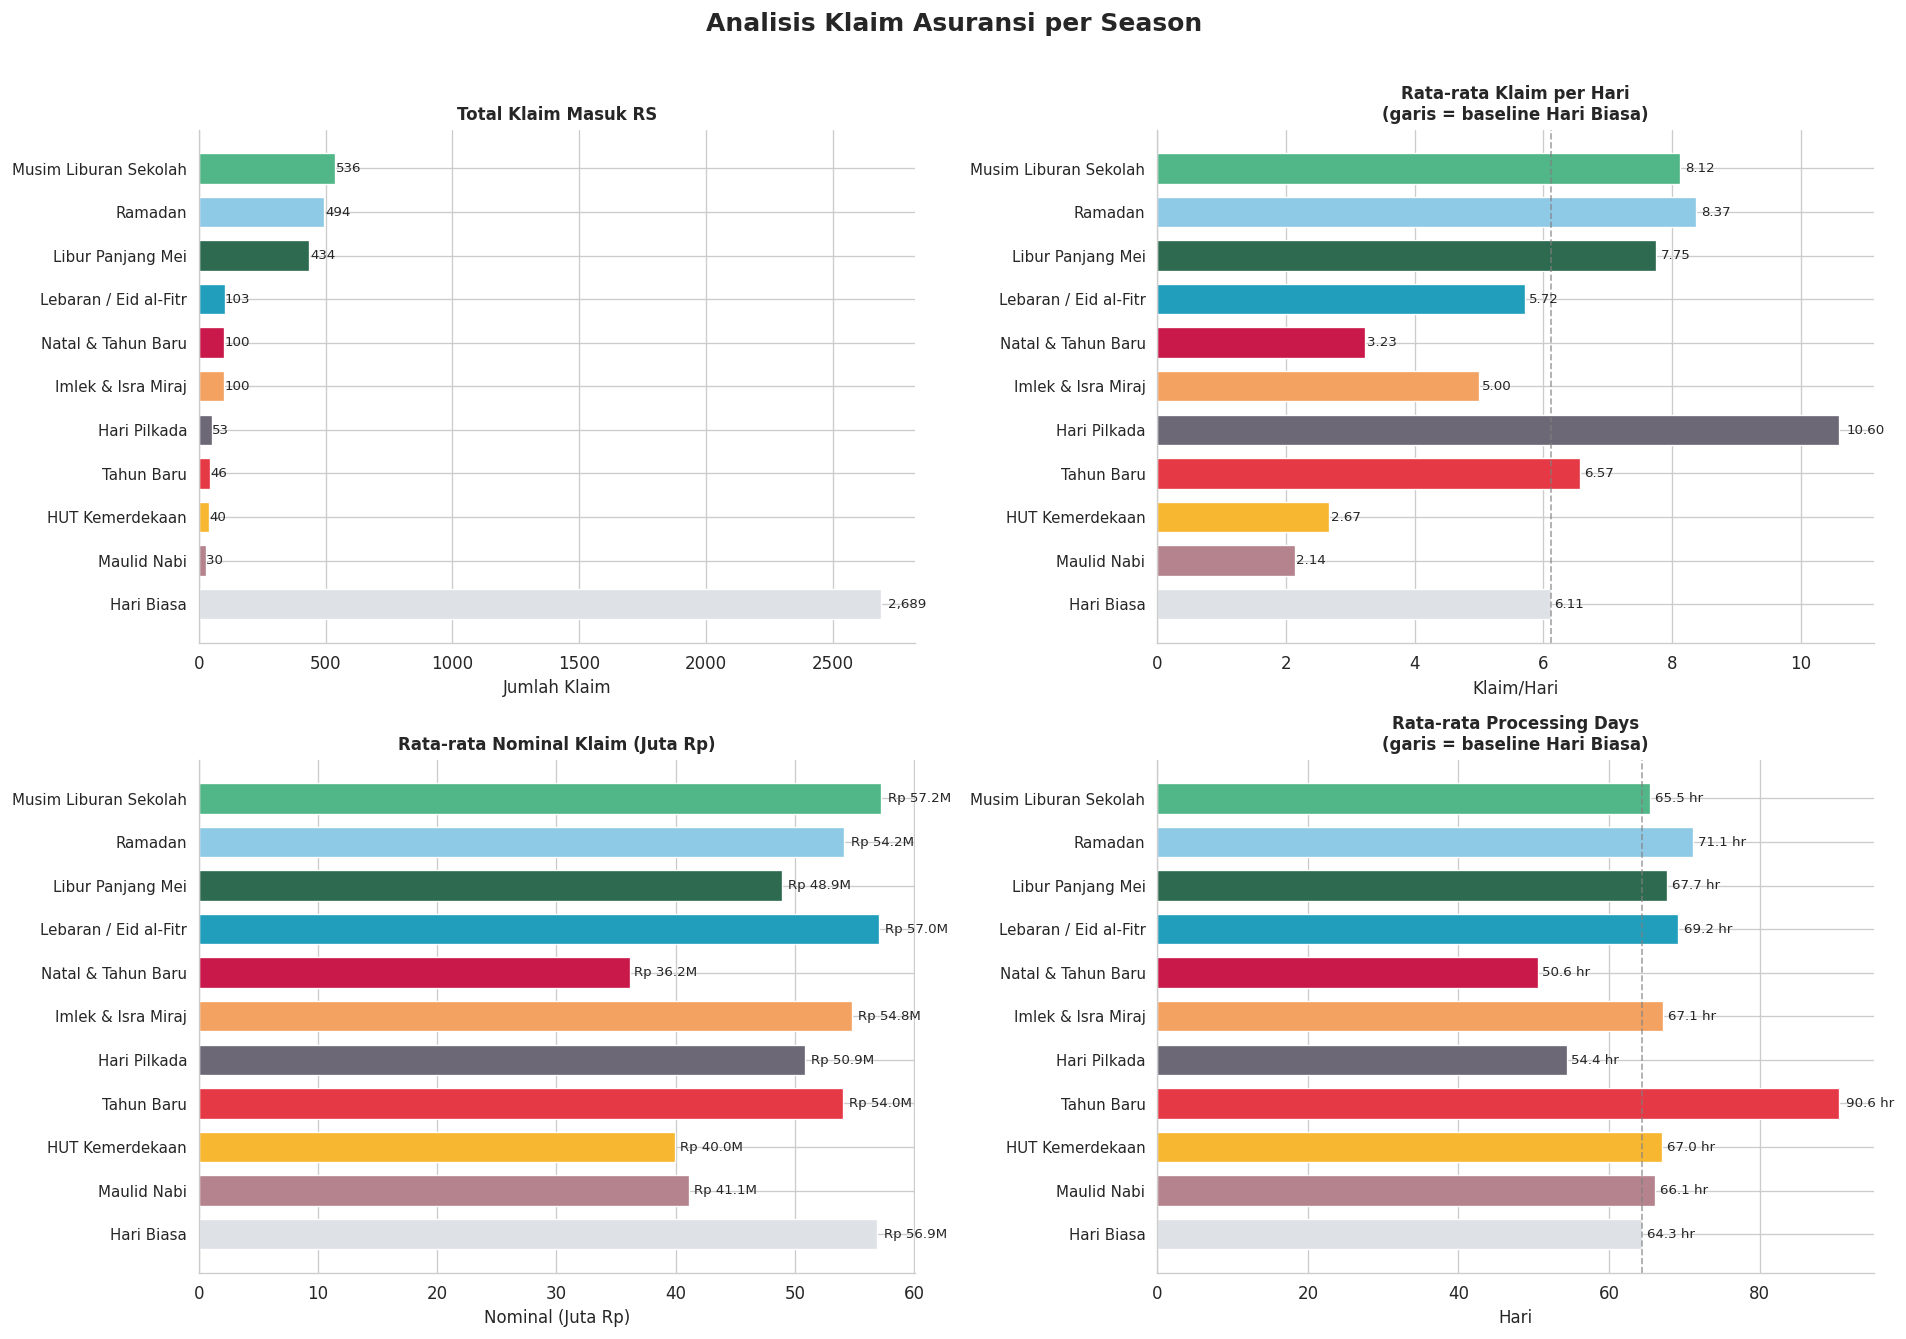

In [6]:
# Warna berurutan sesuai SEASON_PALETTE
def get_color(season):
    return SEASON_PALETTE.get(season, '#ADB5BD')

colors = [get_color(s) for s in agg['season']]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Analisis Klaim Asuransi per Season', fontsize=15, fontweight='bold', y=1.01)

def bar_chart(ax, values, title, ylabel, fmt=None, pct_base=None):
    bars = ax.barh(agg['season'][::-1], values[::-1], color=colors[::-1],
                   edgecolor='white', linewidth=0.8, height=0.7)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel(ylabel)
    for bar, val in zip(bars, values[::-1]):
        label = fmt(val) if fmt else f'{val:.1f}'
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                label, va='center', fontsize=8)
    ax.tick_params(axis='y', labelsize=9)
    ax.spines[['top','right']].set_visible(False)
    # Garis vertikal baseline Hari Biasa
    if pct_base is not None:
        ax.axvline(pct_base, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# Panel 1: Total Klaim
bar_chart(axes[0,0], agg['total_klaim'].values,
          'Total Klaim Masuk RS', 'Jumlah Klaim',
          fmt=lambda x: f'{x:,.0f}')

# Panel 2: Klaim per Hari (normalized)
baseline_kph = float(agg[agg['season']=='Hari Biasa']['klaim_per_hari'].iloc[0])
bar_chart(axes[0,1], agg['klaim_per_hari'].values,
          'Rata-rata Klaim per Hari\n(garis = baseline Hari Biasa)', 'Klaim/Hari',
          fmt=lambda x: f'{x:.2f}',
          pct_base=baseline_kph)

# Panel 3: Avg Nominal Klaim
bar_chart(axes[1,0], agg['avg_nominal'].values / 1e6,
          'Rata-rata Nominal Klaim (Juta Rp)', 'Nominal (Juta Rp)',
          fmt=lambda x: f'Rp {x:.1f}M')

# Panel 4: Avg Processing Days
baseline_proc = float(agg[agg['season']=='Hari Biasa']['avg_proc'].iloc[0])
bar_chart(axes[1,1], agg['avg_proc'].values,
          'Rata-rata Processing Days\n(garis = baseline Hari Biasa)', 'Hari',
          fmt=lambda x: f'{x:.1f} hr',
          pct_base=baseline_proc)

plt.tight_layout()
plt.show()

## 4. Timeline Harian: Klaim & Nominal dengan Blok Season

In [7]:
# Klaim harian
klaim_harian = df.groupby('Tanggal Pasien Masuk RS').agg(
    total_klaim=('Claim ID', 'count'),
    total_nominal=('Nominal Klaim Yang Disetujui', 'sum')
).reset_index().rename(columns={'Tanggal Pasien Masuk RS': 'date'})

# Buat full range kalender
full_cal = pd.DataFrame({'date': pd.date_range('2024-01-01', '2025-12-31')})
full_cal = full_cal.merge(klaim_harian, on='date', how='left')
full_cal = full_cal.merge(df_season[['date','season','season_color']], on='date', how='left')
full_cal['total_klaim'] = full_cal['total_klaim'].fillna(0)
full_cal['total_nominal'] = full_cal['total_nominal'].fillna(0)
full_cal['season'] = full_cal['season'].fillna('Hari Biasa')
full_cal['season_color'] = full_cal['season_color'].fillna(SEASON_PALETTE['Hari Biasa'])
full_cal['rolling7'] = full_cal['total_klaim'].rolling(7, center=True, min_periods=1).mean()
full_cal['rolling7_nom'] = full_cal['total_nominal'].rolling(7, center=True, min_periods=1).mean()

print('Full calendar shape:', full_cal.shape)

Full calendar shape: (731, 7)


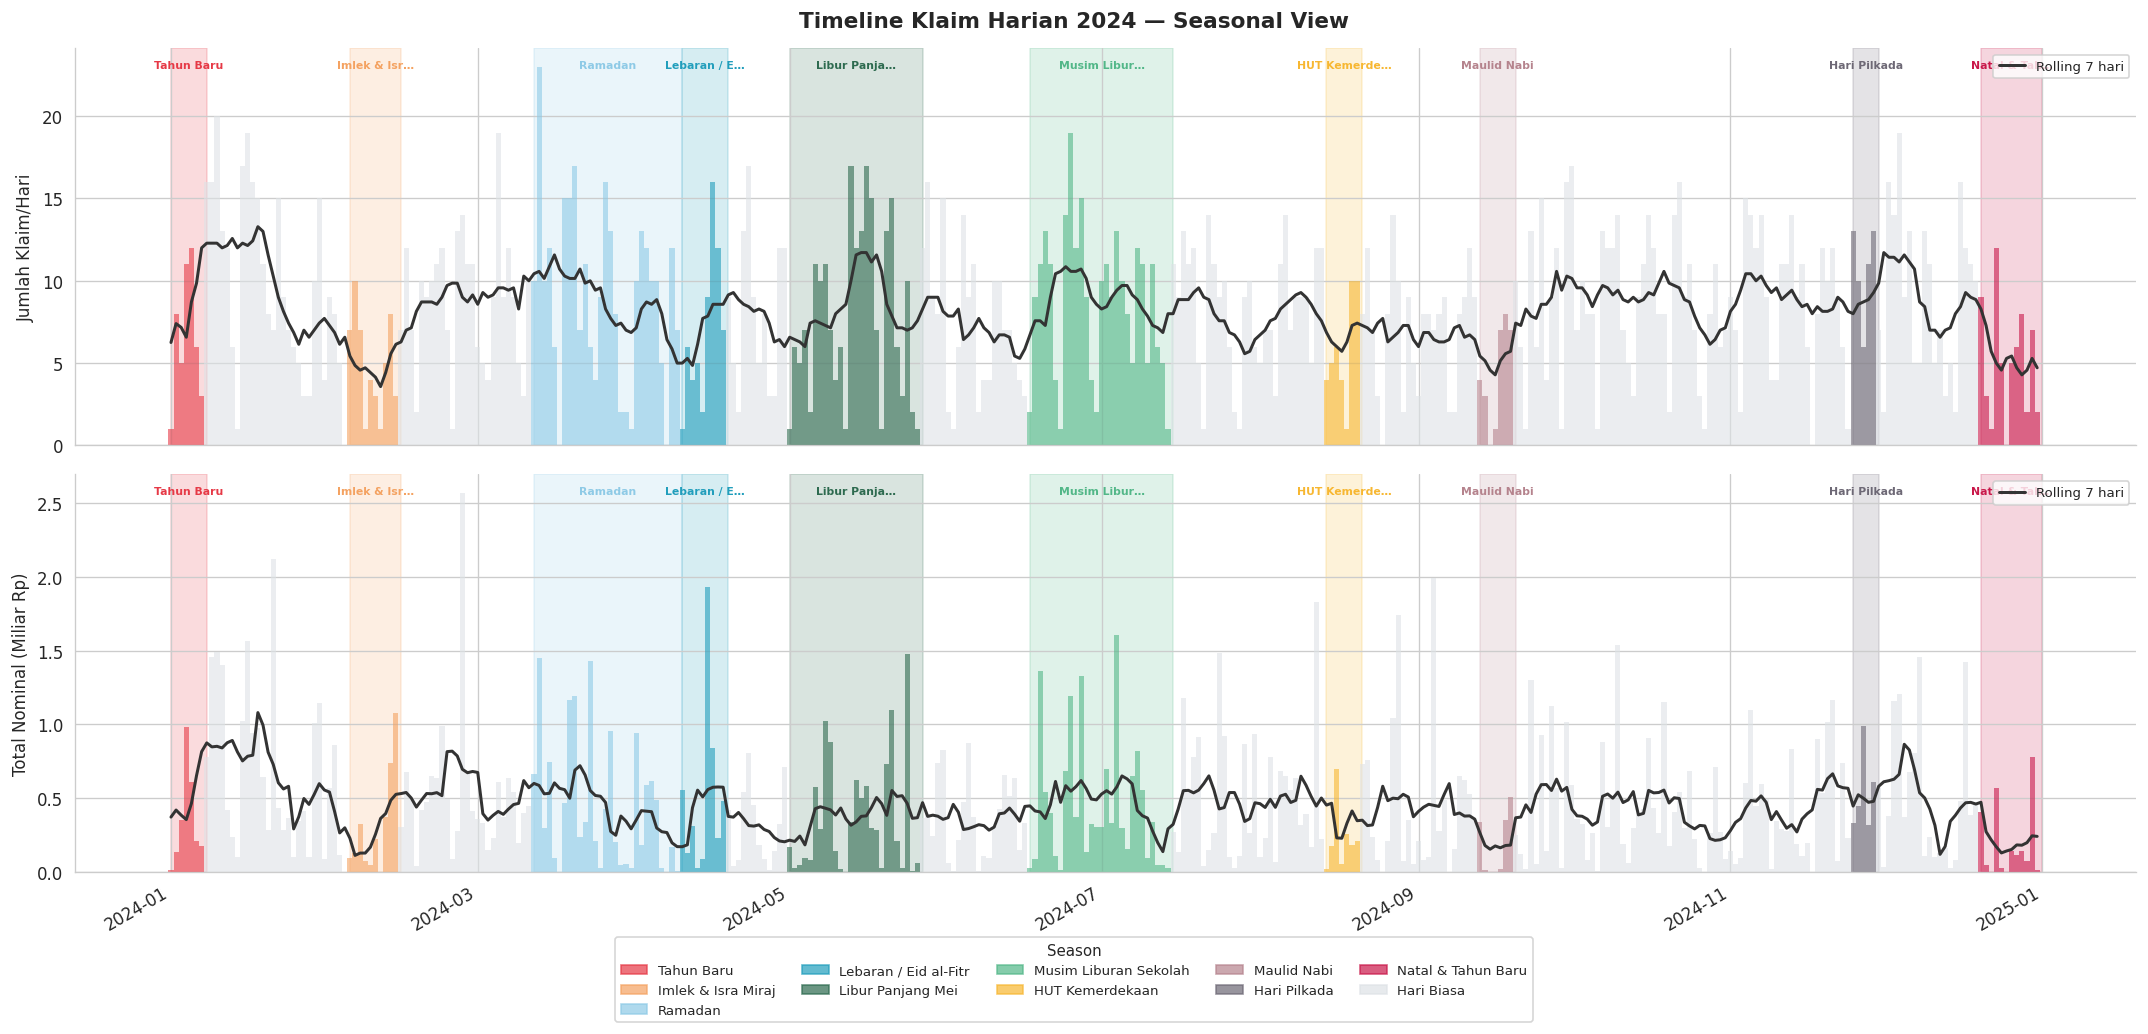

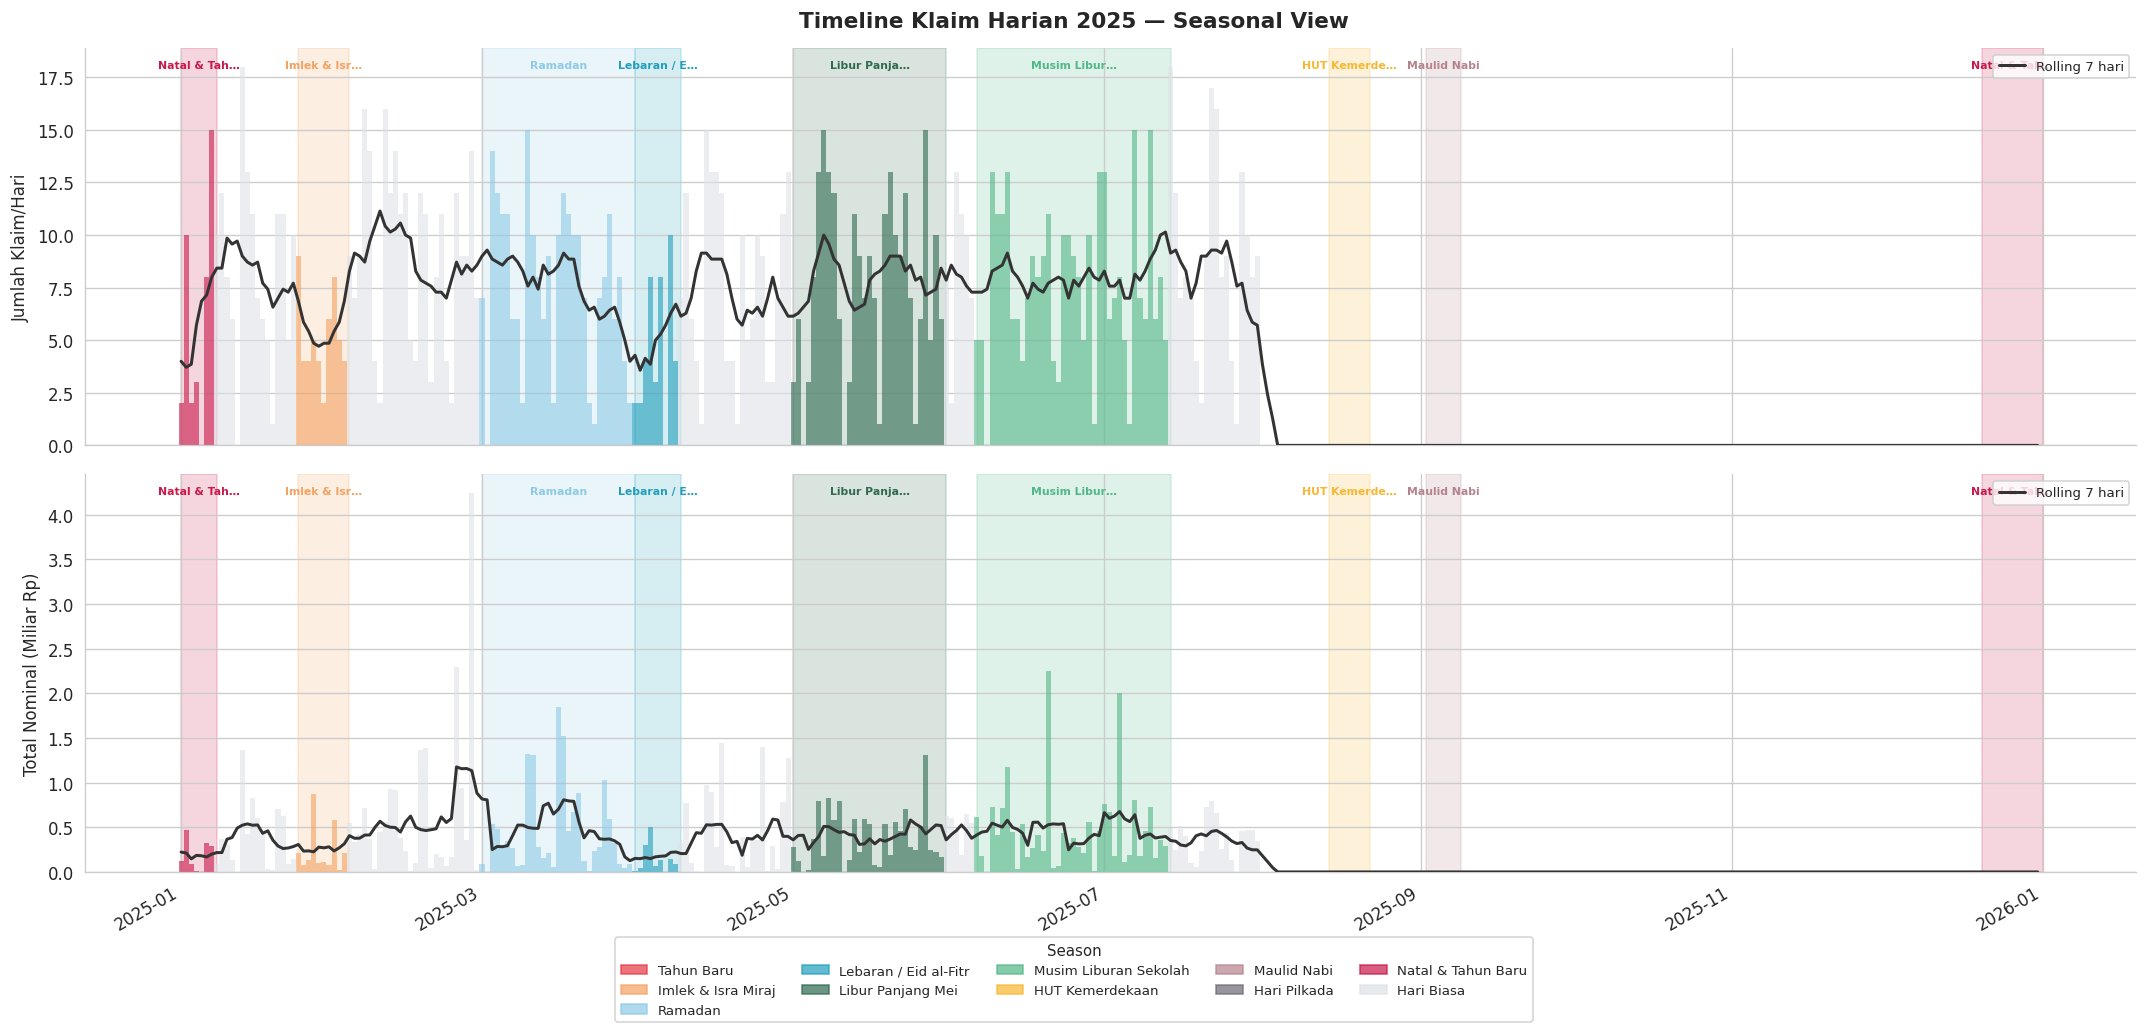

In [8]:
def draw_season_blocks(ax, df_cal, ymin, ymax, alpha=0.18):
    """Gambar blok warna per season sebagai background."""
    df_s = df_cal[df_cal['season'] != 'Hari Biasa'].copy()
    if df_s.empty:
        return
    # Kelompokkan rentang berurutan per season
    df_s = df_s.sort_values('date')
    df_s['grp'] = (df_s['season'] != df_s['season'].shift()) | \
                  (df_s['date'].diff() > pd.Timedelta(days=1))
    df_s['grp'] = df_s['grp'].cumsum()
    for _, grp in df_s.groupby('grp'):
        start = grp['date'].min()
        end   = grp['date'].max() + pd.Timedelta(days=1)
        color = grp['season_color'].iloc[0]
        ax.axvspan(start, end, ymin=ymin, ymax=ymax, color=color, alpha=alpha, zorder=0)
        # Label di tengah blok
        mid = start + (end - start) / 2
        sname = grp['season'].iloc[0]
        short = sname if len(sname) <= 12 else sname[:11] + '…'
        ax.text(mid, ymax * ax.get_ylim()[1] * 0.97, short,
                ha='center', va='top', fontsize=6.5, color=color,
                fontweight='bold', rotation=0, clip_on=True)

# Plot 2024
for year in [2024, 2025]:
    cal_yr = full_cal[full_cal['date'].dt.year == year].copy()

    fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)
    fig.suptitle(f'Timeline Klaim Harian {year} — Seasonal View', fontsize=13, fontweight='bold')

    # Panel 1: Total Klaim
    ax1 = axes[0]
    ax1.bar(cal_yr['date'], cal_yr['total_klaim'],
            color=cal_yr['season_color'], alpha=0.6, width=1.0, edgecolor='none', zorder=2)
    ax1.plot(cal_yr['date'], cal_yr['rolling7'], color='#333333',
             linewidth=1.8, zorder=3, label='Rolling 7 hari')
    draw_season_blocks(ax1, cal_yr, 0, 1)
    ax1.set_ylabel('Jumlah Klaim/Hari')
    ax1.set_ylim(bottom=0)
    ax1.legend(fontsize=8, loc='upper right')
    ax1.spines[['top','right']].set_visible(False)

    # Panel 2: Nominal
    ax2 = axes[1]
    ax2.bar(cal_yr['date'], cal_yr['total_nominal'] / 1e9,
            color=cal_yr['season_color'], alpha=0.6, width=1.0, edgecolor='none', zorder=2)
    ax2.plot(cal_yr['date'], cal_yr['rolling7_nom'] / 1e9, color='#333333',
             linewidth=1.8, zorder=3, label='Rolling 7 hari')
    draw_season_blocks(ax2, cal_yr, 0, 1)
    ax2.set_ylabel('Total Nominal (Miliar Rp)')
    ax2.set_ylim(bottom=0)
    ax2.legend(fontsize=8, loc='upper right')
    ax2.spines[['top','right']].set_visible(False)
    fig.autofmt_xdate()

    # Legend season
    legend_patches = [
        mpatches.Patch(color=color, alpha=0.7, label=name)
        for name, color in SEASON_PALETTE.items()
    ]
    fig.legend(handles=legend_patches, loc='lower center', ncol=5,
               fontsize=8, frameon=True, title='Season', title_fontsize=9,
               bbox_to_anchor=(0.5, -0.08))

    plt.tight_layout()
    plt.show()

## 5. Perbandingan Season: Total Klaim, Nominal, & Processing Days

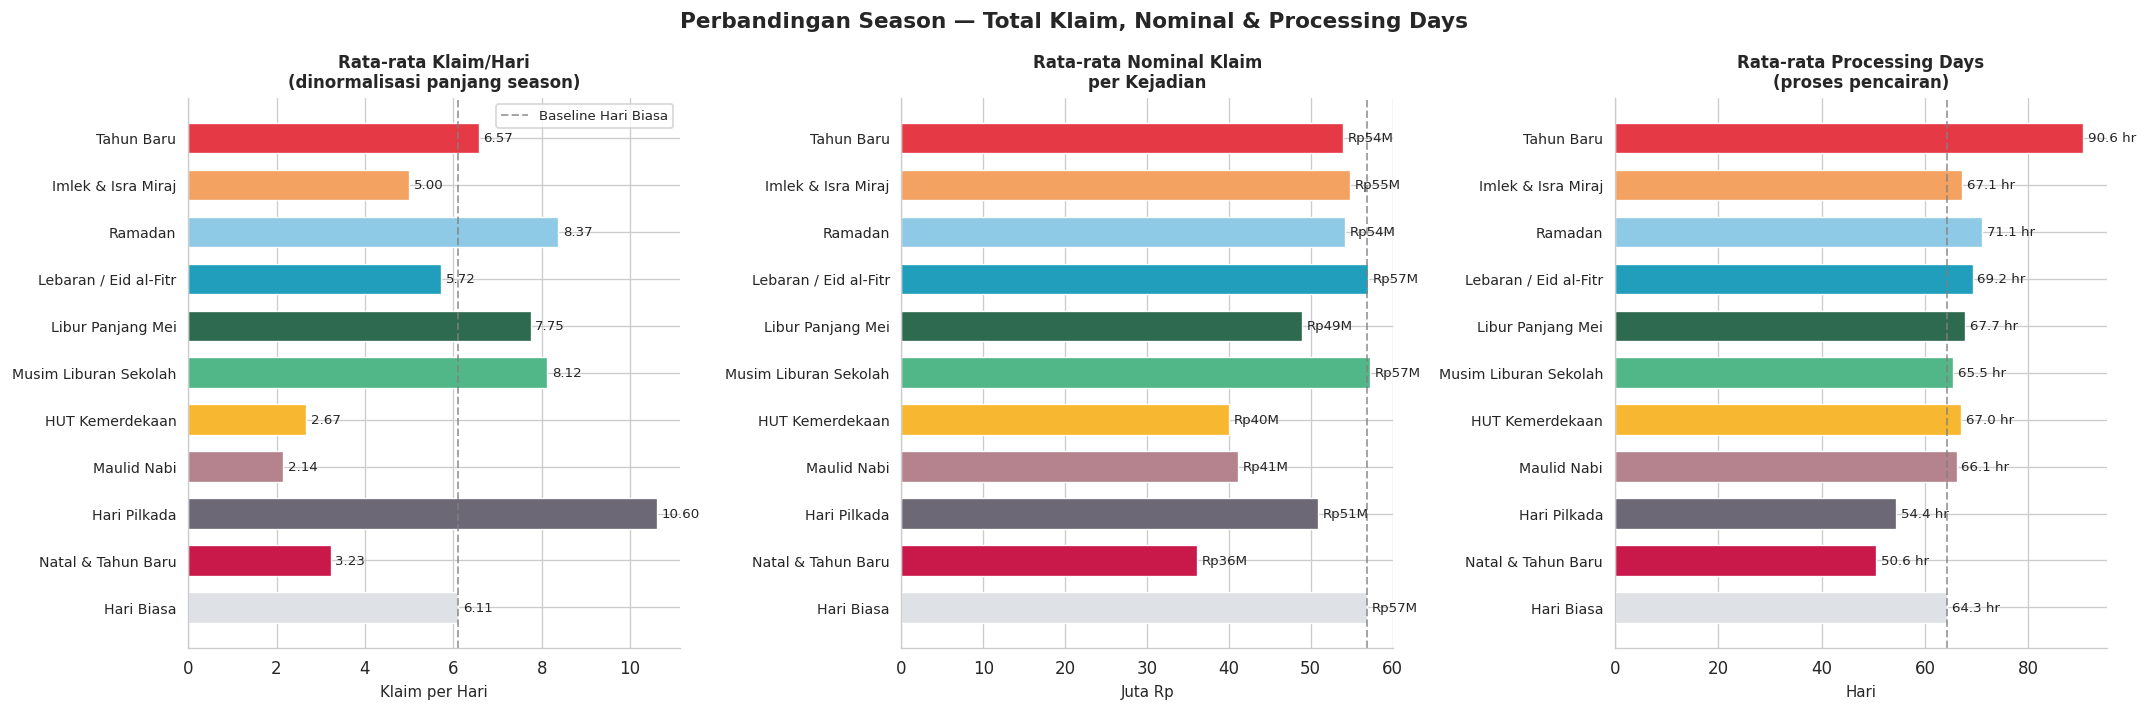

In [9]:
# Urutan season sesuai kalender (bukan by count)
SEASON_ORDER = [
    'Tahun Baru', 'Imlek & Isra Miraj', 'Ramadan', 'Lebaran / Eid al-Fitr',
    'Libur Panjang Mei', 'Musim Liburan Sekolah', 'HUT Kemerdekaan',
    'Maulid Nabi', 'Hari Pilkada', 'Natal & Tahun Baru', 'Hari Biasa'
]
agg_ordered = agg.set_index('season').reindex(SEASON_ORDER).dropna(how='all').reset_index()
colors_ord = [get_color(s) for s in agg_ordered['season']]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Perbandingan Season — Total Klaim, Nominal & Processing Days', fontsize=13, fontweight='bold')

def hbar(ax, vals, title, xlabel, fmt_fn):
    bars = ax.barh(agg_ordered['season'], vals, color=colors_ord,
                   edgecolor='white', linewidth=0.8, height=0.65)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel(xlabel, fontsize=9)
    for bar, v in zip(bars, vals):
        if pd.notna(v):
            ax.text(bar.get_width() + max(vals)*0.01, bar.get_y() + bar.get_height()/2,
                    fmt_fn(v), va='center', fontsize=8)
    ax.invert_yaxis()
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='y', labelsize=8.5)

hbar(axes[0], agg_ordered['klaim_per_hari'].fillna(0).values,
     'Rata-rata Klaim/Hari\n(dinormalisasi panjang season)',
     'Klaim per Hari', lambda x: f'{x:.2f}')

hbar(axes[1], (agg_ordered['avg_nominal'].fillna(0) / 1e6).values,
     'Rata-rata Nominal Klaim\nper Kejadian',
     'Juta Rp', lambda x: f'Rp{x:.0f}M')

hbar(axes[2], agg_ordered['avg_proc'].fillna(0).values,
     'Rata-rata Processing Days\n(proses pencairan)',
     'Hari', lambda x: f'{x:.1f} hr')

# Garis baseline Hari Biasa
baseline_row = agg_ordered[agg_ordered['season'] == 'Hari Biasa']
if not baseline_row.empty:
    axes[0].axvline(baseline_row['klaim_per_hari'].values[0], color='gray',
                    linestyle='--', linewidth=1.2, alpha=0.7, label='Baseline Hari Biasa')
    axes[1].axvline(baseline_row['avg_nominal'].values[0]/1e6, color='gray',
                    linestyle='--', linewidth=1.2, alpha=0.7)
    axes[2].axvline(baseline_row['avg_proc'].values[0], color='gray',
                    linestyle='--', linewidth=1.2, alpha=0.7)
    axes[0].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Heatmap: Klaim Mingguan per Season

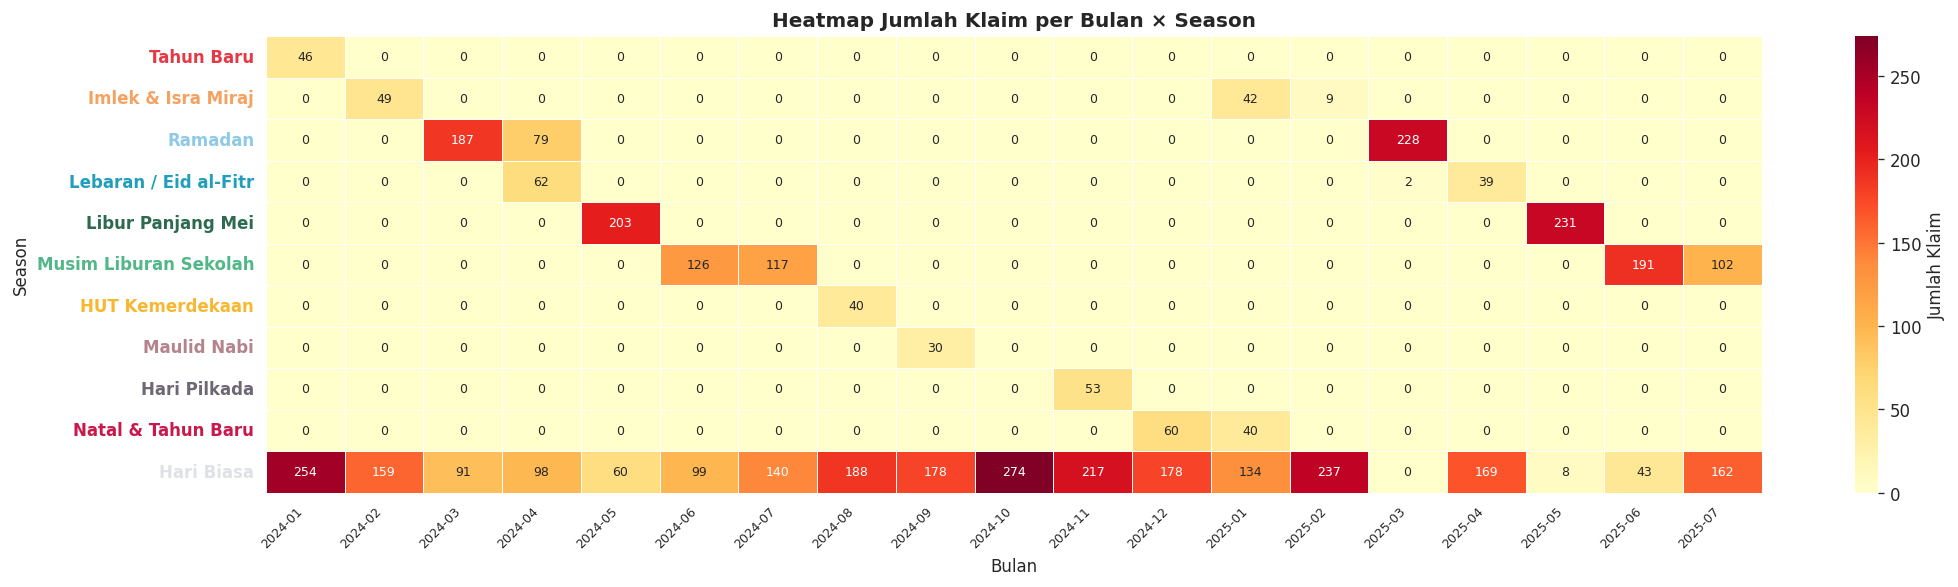

In [10]:
# Agregasi mingguan
full_cal['week'] = full_cal['date'].dt.isocalendar().week.astype(int)
full_cal['year'] = full_cal['date'].dt.year
full_cal['week_label'] = full_cal['date'].dt.strftime('W%V\n%b')
full_cal['month'] = full_cal['date'].dt.to_period('M').astype(str)

# Monthly x Season heatmap
monthly_season = df.groupby(['Bulan', 'season']).size().reset_index(name='count')
pivot = monthly_season.pivot_table(index='season', columns='Bulan', values='count', fill_value=0)
pivot = pivot.reindex([s for s in SEASON_ORDER if s in pivot.index])

fig, ax = plt.subplots(figsize=(18, 5))

# Custom colormap per row (season color)
import matplotlib.colors as mcolors
sns.heatmap(pivot, ax=ax, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.4, cbar_kws={'label': 'Jumlah Klaim'},
            annot_kws={'size': 7.5})

# Warnai label y sesuai season
for ytick, season_name in zip(ax.get_yticklabels(), pivot.index):
    ytick.set_color(get_color(season_name))
    ytick.set_fontweight('bold')

ax.set_title('Heatmap Jumlah Klaim per Bulan × Season', fontsize=12, fontweight='bold')
ax.set_xlabel('Bulan')
ax.set_ylabel('Season')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7.5)

plt.tight_layout()
plt.show()

## 7. Distribusi Processing Days per Season (Violin + Strip)

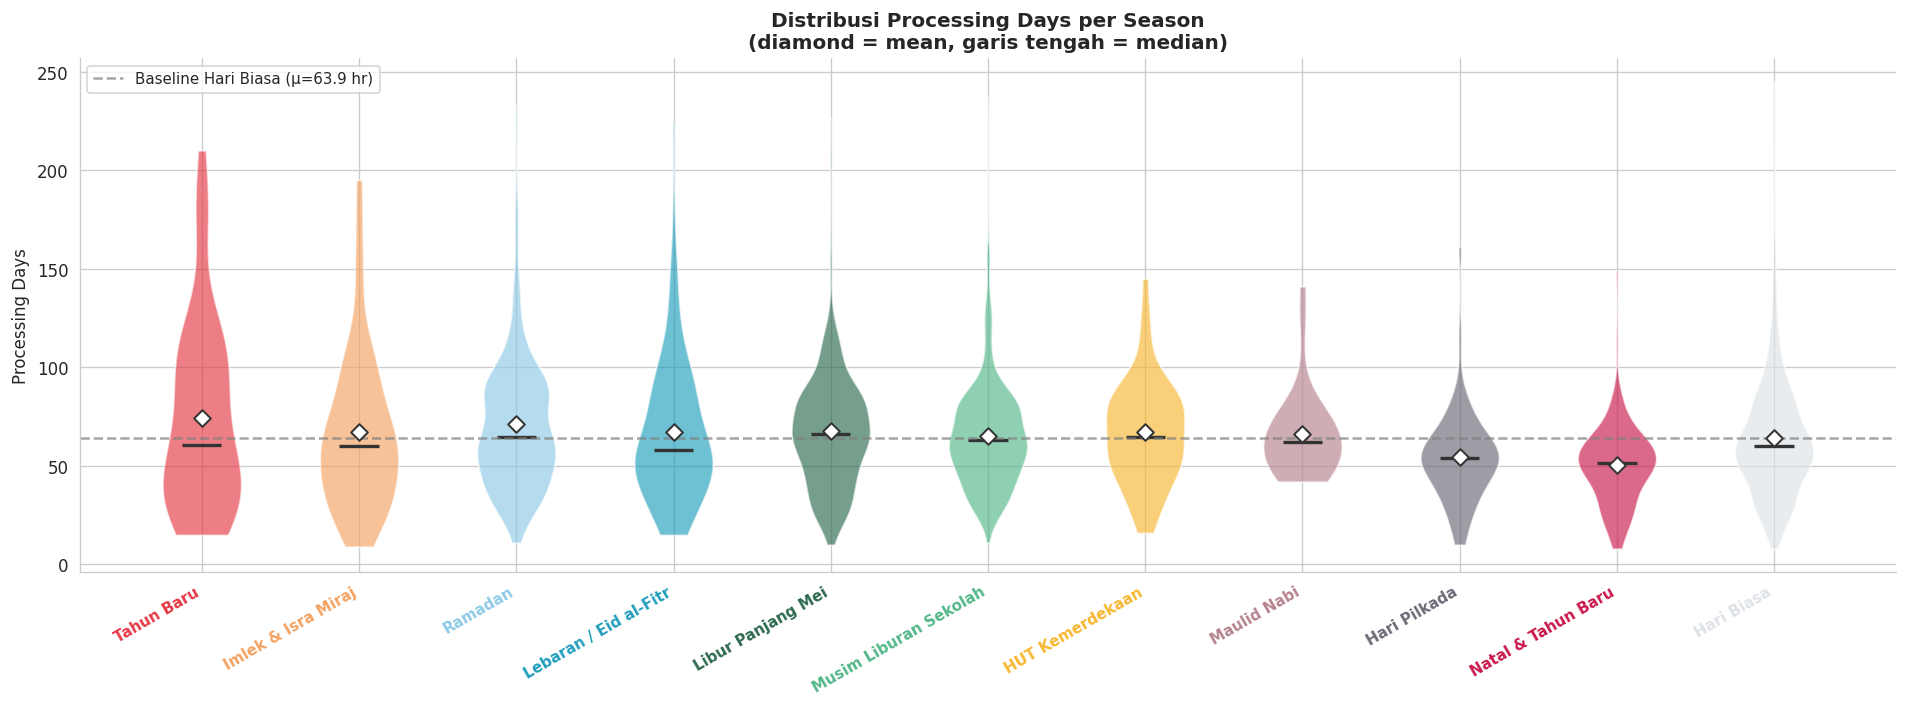

In [11]:
df_proc = df[(df['Processing_Days'].notna()) & (df['Processing_Days'] <= 250)].copy()
df_proc = df_proc[df_proc['season'].isin(SEASON_ORDER)]
df_proc['season'] = pd.Categorical(df_proc['season'], categories=SEASON_ORDER, ordered=True)
df_proc_sorted = df_proc.sort_values('season')

season_present = [s for s in SEASON_ORDER if s in df_proc['season'].values]

fig, ax = plt.subplots(figsize=(16, 6))

# Violin plot
parts = ax.violinplot(
    [df_proc[df_proc['season'] == s]['Processing_Days'].dropna().values for s in season_present],
    positions=range(len(season_present)),
    showmedians=True, showextrema=False
)

for i, (body, season_name) in enumerate(zip(parts['bodies'], season_present)):
    body.set_facecolor(get_color(season_name))
    body.set_alpha(0.65)
    body.set_edgecolor('white')

parts['cmedians'].set_color('#333333')
parts['cmedians'].set_linewidth(2)

# Mean sebagai titik
means = [df_proc[df_proc['season'] == s]['Processing_Days'].mean() for s in season_present]
ax.scatter(range(len(season_present)), means, color='white', edgecolors='#333333',
           zorder=5, s=50, marker='D', linewidths=1.2)

# Garis baseline Hari Biasa
if 'Hari Biasa' in df_proc['season'].values:
    baseline = df_proc[df_proc['season'] == 'Hari Biasa']['Processing_Days'].mean()
    ax.axhline(baseline, color='gray', linestyle='--', linewidth=1.5, alpha=0.7,
               label=f'Baseline Hari Biasa (μ={baseline:.1f} hr)')
    ax.legend(fontsize=9)

ax.set_xticks(range(len(season_present)))
ax.set_xticklabels(season_present, rotation=30, ha='right', fontsize=9)

# Warnai x tick labels
for tick, sname in zip(ax.get_xticklabels(), season_present):
    tick.set_color(get_color(sname))
    tick.set_fontweight('bold')

ax.set_ylabel('Processing Days')
ax.set_title('Distribusi Processing Days per Season\n(diamond = mean, garis tengah = median)',
             fontweight='bold')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

## 8. Ringkasan Tabel per Season

In [12]:
summary = agg_ordered[['season', 'total_klaim', 'n_hari_season', 'klaim_per_hari',
                        'avg_nominal', 'total_nominal', 'avg_proc', 'median_proc']].copy()

# Format untuk tampilan
summary_disp = summary.copy()
summary_disp['klaim_per_hari'] = summary_disp['klaim_per_hari'].round(2)
summary_disp['avg_nominal'] = summary_disp['avg_nominal'].apply(lambda x: f'Rp {x/1e6:.1f}M' if pd.notna(x) else '-')
summary_disp['total_nominal'] = summary_disp['total_nominal'].apply(lambda x: f'Rp {x/1e9:.1f}B' if pd.notna(x) else '-')
summary_disp['avg_proc'] = summary_disp['avg_proc'].round(1)
summary_disp['median_proc'] = summary_disp['median_proc'].round(1)
summary_disp = summary_disp.rename(columns={
    'season': 'Season',
    'total_klaim': 'Total Klaim',
    'n_hari_season': 'Jumlah Hari',
    'klaim_per_hari': 'Klaim/Hari',
    'avg_nominal': 'Avg Nominal',
    'total_nominal': 'Total Nominal',
    'avg_proc': 'Avg Proc (hr)',
    'median_proc': 'Med Proc (hr)'
})

print('=' * 95)
print('RINGKASAN ANALISIS KLAIM per SEASON')
print('=' * 95)
print(summary_disp.to_string(index=False))

# Insight otomatis
biasa = summary[summary['season'] == 'Hari Biasa'].iloc[0]
print('\n--- KEY INSIGHTS ---')
for _, row in summary[summary['season'] != 'Hari Biasa'].iterrows():
    if pd.notna(row['klaim_per_hari']) and row['klaim_per_hari'] > 0:
        delta_kph = (row['klaim_per_hari'] - biasa['klaim_per_hari']) / biasa['klaim_per_hari'] * 100
        delta_proc = row['avg_proc'] - biasa['avg_proc'] if pd.notna(row['avg_proc']) else float('nan')
        arah_k = '↑' if delta_kph > 0 else '↓'
        arah_p = '↑' if delta_proc > 0 else '↓'
        proc_str = f' | Proses pencairan {arah_p}{abs(delta_proc):.1f} hr vs hari biasa' if pd.notna(delta_proc) else ''
        print(f"  {row['season']}: volume klaim {arah_k}{abs(delta_kph):.1f}%{proc_str}")

RINGKASAN ANALISIS KLAIM per SEASON
               Season  Total Klaim  Jumlah Hari  Klaim/Hari Avg Nominal Total Nominal  Avg Proc (hr)  Med Proc (hr)
           Tahun Baru           46            7        6.57    Rp 54.0M       Rp 2.5B           90.6           64.5
   Imlek & Isra Miraj          100           20        5.00    Rp 54.8M       Rp 5.5B           67.1           60.0
              Ramadan          494           59        8.37    Rp 54.2M      Rp 26.8B           71.1           64.5
Lebaran / Eid al-Fitr          103           18        5.72    Rp 57.0M       Rp 5.9B           69.2           58.0
    Libur Panjang Mei          434           56        7.75    Rp 48.9M      Rp 21.2B           67.7           66.0
Musim Liburan Sekolah          536           66        8.12    Rp 57.2M      Rp 30.7B           65.5           63.0
      HUT Kemerdekaan           40           15        2.67    Rp 40.0M       Rp 1.6B           67.0           64.5
          Maulid Nabi           30  